# Phase 3: 模型验证 (Model Validation)

## 概述 Overview

本Notebook实现Phase 3的二分类建模与迁移学习验证。

**主要任务：**
1. **标签二值化**: 基于中位数将稳定性分为"稳定"vs"不稳定"
2. **交叉验证**: 5折分层CV，训练LR/RF/XGBoost三种模型
3. **特征重要性**: 分析最具预测性的分子特征
4. **迁移学习**: 评估模型在不同数据集间的泛化能力
5. **结果可视化**: 混淆矩阵、性能对比、迁移热力图

**模型配置：**
- Logistic Regression: L2正则化, balanced权重
- Random Forest: 100棵树, balanced权重
- XGBoost: GPU加速, max_depth=6, balanced权重

**输入**: 
- `data/processed/*.csv` - 带分钟标签的CSV  
- `outputs/features/*.npz` - RDKit特征矩阵  

**输出**: 
- `outputs/model_results/phase3_binary/cv_results/` - CV结果JSON  
- `outputs/model_results/phase3_binary/feature_importance/` - 特征重要性CSV  
- `outputs/model_results/phase3_binary/transfer_results/` - 迁移学习JSON  
- `outputs/figures/phase3/` - 可视化图表  

---

## 1. 环境检查与导入 Environment Setup

In [31]:
# 环境检查
import sys
from pathlib import Path

# 添加项目根目录到路径
project_root = Path.cwd().parent
print(project_root)
sys.path.insert(0, str(project_root / "src"))

# 核心库导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import json
warnings.filterwarnings('ignore')

# 机器学习
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from xgboost import XGBClassifier

# 检查GPU可用性
try:
    import torch
    gpu_available = torch.cuda.is_available()
    if gpu_available:
        print(f"✓ GPU可用: {torch.cuda.get_device_name(0)}")
    else:
        print("⚠ GPU不可用，将使用CPU训练")
except ImportError:
    gpu_available = False
    print("⚠ PyTorch未安装，将使用CPU训练")

# 设置显示选项
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ 所有库已成功导入")
print(f"✓ 项目根目录: {project_root}")

d:\RA\feature_extraction
⚠ GPU不可用，将使用CPU训练
✓ 所有库已成功导入
✓ 项目根目录: d:\RA\feature_extraction


In [32]:

def convert_numpy_types(obj):
    """递归转换numpy类型为Python原生类型"""
    import numpy as np
    if isinstance(obj, dict):
        return {k: convert_numpy_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(v) for v in obj]
    elif isinstance(obj, (np.integer, np.int64, np.int32)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64, np.float32)):
        return float(obj)
    elif isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj


## 2. 参数配置区 Configuration

**⚙️ 根据您的需求修改以下参数**

In [33]:
# ============== 参数配置区 ==============

CONFIG = {
    # 输入输出路径
    'processed_dir': project_root / 'data' / 'processed',
    'features_dir': project_root / 'outputs' / 'features',
    'cv_results_dir': project_root / 'outputs' / 'model_results' / 'phase3_binary' / 'cv_results',
    'feature_importance_dir': project_root / 'outputs' / 'model_results' / 'phase3_binary' / 'feature_importance',
    'transfer_results_dir': project_root / 'outputs' / 'model_results' / 'phase3_binary' / 'transfer_results',
    'figures_dir': project_root / 'outputs' / 'figures' / 'phase3',
    
    # 模型选择（可选: 'lr', 'rf', 'xgb'）
    'models_to_train': ['lr', 'rf', 'xgb'],
    
    # 交叉验证参数
    'n_folds': 5,
    'random_state': 42,
    
    # XGBoost参数
    'use_gpu': gpu_available,
    'xgb_max_depth': 6,
    'xgb_learning_rate': 0.1,
    'xgb_n_estimators': 100,
    
    # Random Forest参数
    'rf_n_estimators': 100,
    'rf_n_jobs': -1,
    
    # Logistic Regression参数
    'lr_max_iter': 1000,
    
    # 可视化参数
    'dpi': 300,
    'format': 'png',
    'display_plots': True,
    'max_display_plots': 8,
}

# 创建输出目录
for key in ['cv_results_dir', 'feature_importance_dir', 'transfer_results_dir', 'figures_dir']:
    CONFIG[key].mkdir(parents=True, exist_ok=True)

print("配置参数:")
print(f"  模型: {CONFIG['models_to_train']}")
print(f"  交叉验证折数: {CONFIG['n_folds']}")
print(f"  GPU加速: {CONFIG['use_gpu']}")
print(f"  XGBoost参数: max_depth={CONFIG['xgb_max_depth']}, lr={CONFIG['xgb_learning_rate']}")

配置参数:
  模型: ['lr', 'rf', 'xgb']
  交叉验证折数: 5
  GPU加速: False
  XGBoost参数: max_depth=6, lr=0.1


## 3. 数据加载与二值化 Data Loading & Binarization

In [34]:
def load_and_binarize_dataset(npz_path: Path, csv_path: Path, target: str, is_monomer: bool = None):
    """
    加载数据并将标签二值化，同时可选择只保留monomer或非monomer样本
    (2025-12-15新增功能)
    
    Args:
        npz_path: NPZ特征文件
        csv_path: 处理后的CSV文件（包含分钟标签）
        target: 'SIF' or 'SGF'
        is_monomer: 如果为True，只保留monomer；False，只保留非monomer；None不筛选
    
    Returns:
        X, y_binary, median_threshold, feature_names
    """
    # 加载NPZ特征
    data = np.load(npz_path, allow_pickle=True)
    X = data['X']
    feature_names = data['feature_names']
    ids_npz = data['ids']
    
    # 加载CSV获取分钟标签
    df = pd.read_csv(csv_path)
    df['id'] = df['id'].astype(str)
    
    # ID匹配：这里是建立一个映射数值
    id_to_idx = {str(id_): idx for idx, id_ in enumerate(ids_npz)}
    valid_indices = [] # 确定当前任务用哪一行
    valid_labels = []
    
    label_col = f"{target}_minutes" # 根据任务目标获取分钟数目
    for _, row in df.iterrows():
        row_id = str(row['id'])
        if row_id in id_to_idx:
            #===================================过滤无效标签=========================================
            label= row[label_col]
            if label == -1 or pd.isna(label):# 判断标签有效（对应的任务就只能做对应的二值化）
                continue
            if is_monomer is not None and row['is_monomer'] != is_monomer:  # 判断是否满足monomer条件
                continue
            if row[f"{target}_minutes"]>700: #特殊情况处理，如果是SIF_minuters>700，则视为无效的情况
                continue   
            #=======================================================================================
            # 符合条件则加入
            valid_indices.append(id_to_idx[row_id]) # 获取对应数据的索引/序号
            valid_labels.append(label)              # 获取label
    
    # 筛选有效样本
    X_valid = X[valid_indices]   # 根据序号直接获取到值，这里是numpy的基本用法之一，比如传入【3，7】那么得到的就是第三行和第七行的数值
    y_minutes = np.array(valid_labels)  # 获取y值

    
    
    # 设定阈值========================
    median =None
    if target=='SIF':
        median = 270
    elif target=='SGF':
        median =250   #（经过纠正250更好点）
    
    # 根据阈值判断是否稳定捏
    y_binary = (y_minutes >= median).astype(int)  # 1=稳定, 0=不稳定
    
    print(f"  样本数: {len(X_valid)}")
    print(f"  中位数阈值（更新后阈值根据75%划分得出结果）: {median:.1f} 分钟")
    print(f"  稳定/不稳定: {np.sum(y_binary==1)}/{np.sum(y_binary==0)}")
    
    return X_valid, y_binary, median, feature_names


# 加载所有数据集
datasets_data = {}
npz_files = sorted(CONFIG['features_dir'].glob('*_processed.npz'))
# 选择加载数据的时候就指定monomer或非monomer样本
is_monomer = True # 仅加载monomer样本，设置为False则加载非monomer样本，None则不筛选

print(f"加载并二值化 {len(npz_files)} 个数据集:\n")
for npz_file in npz_files:
    dataset_name = npz_file.stem.replace('_processed', '')
    csv_file = CONFIG['processed_dir'] / f"{dataset_name}_processed.csv"
    
    print(f"{dataset_name}:")

    # 此处新增数据集加载功能（第四个参数）
    
    # SIF
    X_sif, y_sif, median_sif, feat_names = load_and_binarize_dataset(npz_file, csv_file, 'SIF',is_monomer)
    print(f"  SIF数据选择完成，只获得单体数据")
    
    # SGF
    X_sgf, y_sgf, median_sgf, _ = load_and_binarize_dataset(npz_file, csv_file, 'SGF',is_monomer)
    print(f"  SGF数据选择完成，只获取单体数据\n")
    
    datasets_data[dataset_name] = {
        'X_sif': X_sif,
        'y_sif': y_sif,
        'median_sif': median_sif,
        'X_sgf': X_sgf,
        'y_sgf': y_sgf,
        'median_sgf': median_sgf,
        'feature_names': feat_names,
    }

print(f"✓ 数据加载完成！共 {len(datasets_data)} 个数据集")

#=============对数据进行一些处理=========================
# 字典序
#print("查看数据集类型",type(datasets_data))   
# dict_keys(['sif_sgf_second', 'US20140294902A1', 'US9624268', 'US9809623B2', 'WO2017011820A2'])
#print("尝试输出数据查看情况",datasets_data.keys()) 
# 字典序
#print("尝试输出数据查看情况",type(datasets_data['sif_sgf_second'])) 
# dict_keys(['X_sif', 'y_sif', 'median_sif', 'X_sgf', 'y_sgf', 'median_sgf', 'feature_names'])
#print("尝试输出数据查看情况",datasets_data['sif_sgf_second'].keys()) 
# 字典序
#print("尝试输出数据查看情况",type(datasets_data['sif_sgf_second']['X_sif'])) # 数据类型为 <class 'numpy.ndarray'>
# dict_keys(['X_sif', 'y_sif', 'median_sif', 'X_sgf', 'y_sgf', 'median_sgf', 'feature_names'])

# 两种任务的计算结果
#print("X_sif",datasets_data['sif_sgf_second']['X_sif'].shape) 
#print("y_sif",datasets_data['sif_sgf_second']['y_sif'].shape) 
#print("median_sif",datasets_data['sif_sgf_second']['median_sif']) 
#print("X_sgf",datasets_data['sif_sgf_second']['X_sgf'].shape) 
#print("y_sgf",datasets_data['sif_sgf_second']['y_sgf'].shape) 
#print("median_sgf",datasets_data['sif_sgf_second']['median_sgf']) 

#=============上方为数据的处理区域=======================

加载并二值化 5 个数据集:

sif_sgf_second:
  样本数: 202
  中位数阈值（更新后阈值根据75%划分得出结果）: 270.0 分钟
  稳定/不稳定: 0/202
  SIF数据选择完成，只获得单体数据
  样本数: 202
  中位数阈值（更新后阈值根据75%划分得出结果）: 250.0 分钟
  稳定/不稳定: 0/202
  SGF数据选择完成，只获取单体数据

US20140294902A1:
  样本数: 5
  中位数阈值（更新后阈值根据75%划分得出结果）: 270.0 分钟
  稳定/不稳定: 3/2
  SIF数据选择完成，只获得单体数据
  样本数: 0
  中位数阈值（更新后阈值根据75%划分得出结果）: 250.0 分钟
  稳定/不稳定: 0/0
  SGF数据选择完成，只获取单体数据

US9624268:
  样本数: 130
  中位数阈值（更新后阈值根据75%划分得出结果）: 270.0 分钟
  稳定/不稳定: 76/54
  SIF数据选择完成，只获得单体数据
  样本数: 90
  中位数阈值（更新后阈值根据75%划分得出结果）: 250.0 分钟
  稳定/不稳定: 52/38
  SGF数据选择完成，只获取单体数据

US9809623B2:
  样本数: 26
  中位数阈值（更新后阈值根据75%划分得出结果）: 270.0 分钟
  稳定/不稳定: 5/21
  SIF数据选择完成，只获得单体数据
  样本数: 5
  中位数阈值（更新后阈值根据75%划分得出结果）: 250.0 分钟
  稳定/不稳定: 5/0
  SGF数据选择完成，只获取单体数据

WO2017011820A2:
  样本数: 150
  中位数阈值（更新后阈值根据75%划分得出结果）: 270.0 分钟
  稳定/不稳定: 92/58
  SIF数据选择完成，只获得单体数据
  样本数: 105
  中位数阈值（更新后阈值根据75%划分得出结果）: 250.0 分钟
  稳定/不稳定: 65/40
  SGF数据选择完成，只获取单体数据

✓ 数据加载完成！共 5 个数据集


## 4. 交叉训练的验证结果以及相关内容

新增：模型选取的时候自动使用随机种子

新增：自动调整数据集顺序

In [35]:
import random
def get_model(model_name: str, use_gpu: bool = False):
    """
    创建模型实例
    """
    if model_name == 'lr':
        return LogisticRegression(
            max_iter=CONFIG['lr_max_iter'],
            class_weight='balanced',
            random_state=random.randint(1, 1000000)#  CONFIG['random_state']
        )
    elif model_name == 'rf':
        return RandomForestClassifier(
            n_estimators=CONFIG['rf_n_estimators'],
            class_weight='balanced',
            n_jobs=CONFIG['rf_n_jobs'],
            random_state=random.randint(1, 1000000)#CONFIG['random_state']
        )
    elif model_name == 'xgb':
        params = {
            'max_depth': CONFIG['xgb_max_depth'],
            'learning_rate': CONFIG['xgb_learning_rate'],
            'n_estimators': CONFIG['xgb_n_estimators'],
            'random_state': random.randint(1, 1000000),#CONFIG['random_state'],
            'tree_method': 'hist',
        }
        if use_gpu:
            params['device'] = 'cuda:0'
        return XGBClassifier(**params)
    else:
        raise ValueError(f"Unknown model: {model_name}")

def cross_validate_model(X, y, model_name: str, dataset_name: str, target: str):
    """
    执行k折交叉验证
    
    Returns:
        dict: CV结果
    """
    # 自动调整fold数（小数据集）
    min_class_count = np.bincount(y).min()
    n_folds = min(CONFIG['n_folds'], min_class_count)
    if n_folds < CONFIG['n_folds']:
        print(f"    ⚠ 样本数较少，调整fold数为 {n_folds}")
    
    if n_folds < 2:
        print("    ⚠ 样本过少，无法进行分层交叉验证，跳过该任务")
        return None

    
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=CONFIG['random_state'])
    
    metrics = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': []
    }
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # 训练模型
        model = get_model(model_name, CONFIG['use_gpu'])
        model.fit(X_train, y_train)
        
        # 预测
        y_pred = model.predict(X_test)
        # （修改后的probo）
        proba = model.predict_proba(X_test)
        if proba.shape[1] == 2:
            y_proba = proba[:, 1]
        else:
            y_proba = None  # 只有一个类别时，AUC 没有定义
        
        # 计算指标
        metrics['accuracy'].append(accuracy_score(y_test, y_pred))
        metrics['precision'].append(precision_score(y_test, y_pred, average='binary', zero_division=0))
        metrics['recall'].append(recall_score(y_test, y_pred, average='binary', zero_division=0))
        metrics['f1'].append(f1_score(y_test, y_pred, average='binary', zero_division=0))
        
        # AUC（需要至少两个类别，新增一种情况与下面配合，就是只有一种类别）
        if y_proba is not None and len(np.unique(y_test)) > 1:
            metrics['auc'].append(roc_auc_score(y_test, y_proba))
        else:
            metrics['auc'].append(np.nan)
    
    # 汇总结果
    results = {
        'dataset': dataset_name,
        'target': target,
        'model': model_name,
        'n_folds': n_folds,
        'metrics': metrics,
        'mean_metrics': {k: np.nanmean(v) for k, v in metrics.items()},
        'std_metrics': {k: np.nanstd(v) for k, v in metrics.items()},
    }
    
    return results

## 6. 迁移学习 Transfer Learning

评估模型在不同数据集间的泛化能力（Train on A, Test on B）


开始迁移学习训练并即时可视化...

迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移第3次
迁移第4次
迁移第5次
迁移第6次
迁移第7次
迁移第8次
迁移第9次
迁移第0次
迁移第1次
迁移第2次
迁移

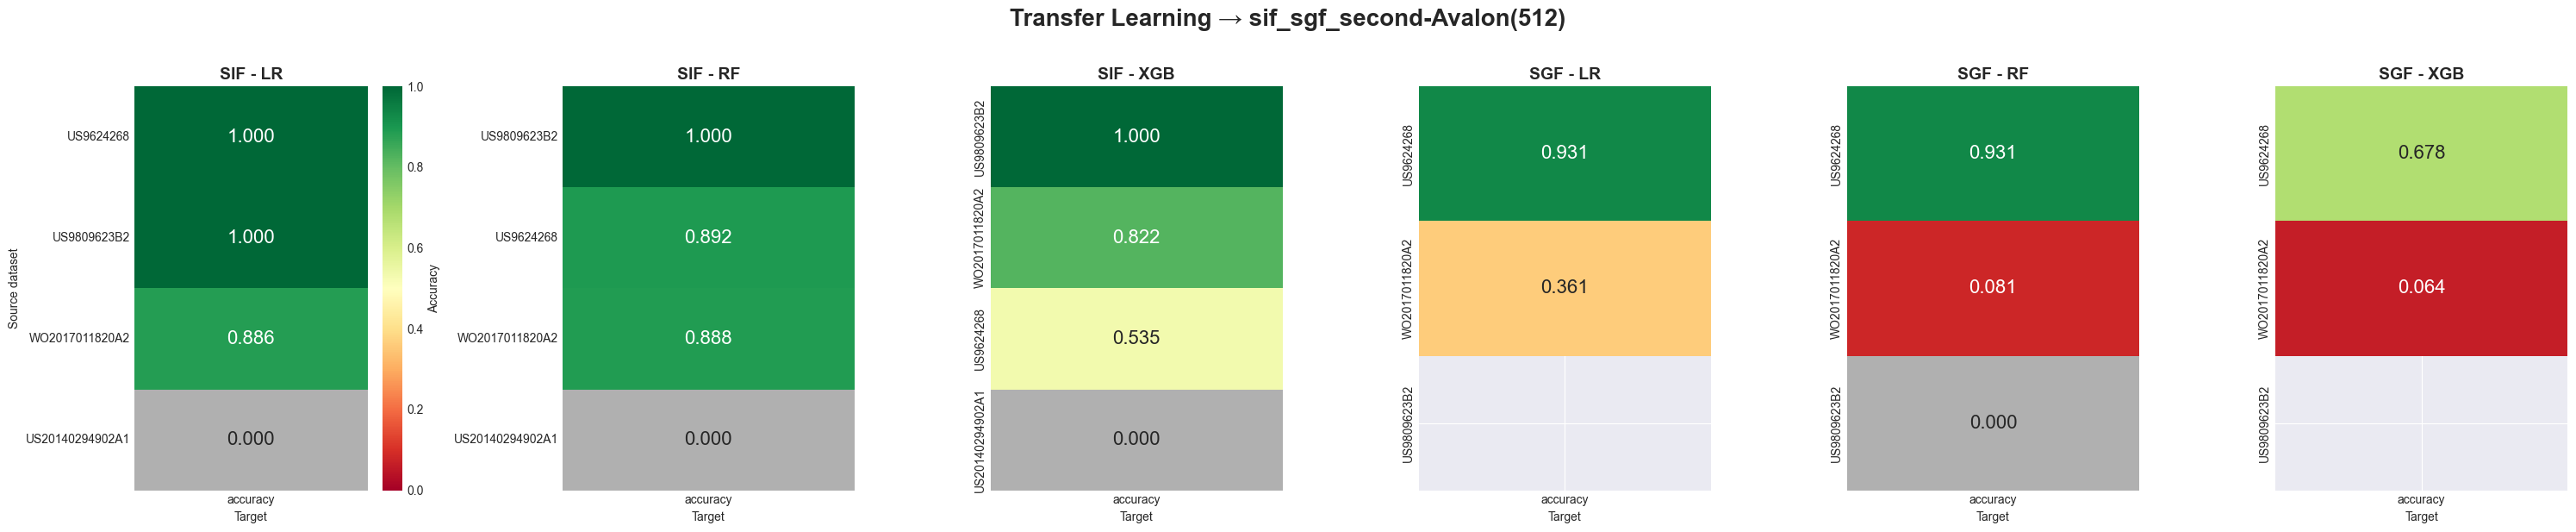

In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json  # 新增

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# =====================================================
# 1. 单次迁移训练函数
# =====================================================

def transfer_learning_test(
    X_train, y_train,
    X_test, y_test,
    model_name: str,
    use_gpu: bool = False
):
    """
    单次 source → target 迁移学习
    """
    model = get_model(model_name, use_gpu)

    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    except Exception:
        return None

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        #"auc":roc_auc_score(y_test, y_pred),
        "confusion_matrix": confusion_matrix(y_test, y_pred).tolist()
    }

# ===========================
# 1.1 多次进行迁移学习并且输出均值
# ===========================
def transfer_learning_test_mean(
    X_train, y_train,
    X_test, y_test,
    model_name: str,
    use_gpu: bool = False,
    n_runs: int = 10,
    random_seed: int = 42
):
    """
    多次 source → target 迁移学习，并对结果取均值
    """
    metrics_list = []

    for i in range(n_runs):
        print(f"迁移第{i}次")
        model = get_model(model_name, use_gpu)

        # 如果模型支持随机种子，尽量固定
        if hasattr(model, "random_state"):
            model.random_state = random_seed + i

        try:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        except Exception:
            continue

        metrics_list.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "confusion_matrix": confusion_matrix(y_test, y_pred, labels=[0, 1])
        })

    if len(metrics_list) == 0:
        return None

    # ===== 取均值 =====
    mean_metrics = {
        "accuracy": float(np.mean([m["accuracy"] for m in metrics_list])),
        "precision": float(np.mean([m["precision"] for m in metrics_list])),
        "recall": float(np.mean([m["recall"] for m in metrics_list])),
        "f1": float(np.mean([m["f1"] for m in metrics_list])),
        "confusion_matrix": (
            np.mean([m["confusion_matrix"] for m in metrics_list], axis=0)
            .tolist()
        )
    }

    return mean_metrics

# =====================================================
# 2. 执行迁移学习（多 source → 单 target）
# =====================================================

print("\n开始迁移学习训练并即时可视化...\n")

TARGET_DATASET = "sif_sgf_second"   # ⭐ 你只需要改这里

transfer_results = []

dataset_names = list(datasets_data.keys())

for train_dataset in dataset_names:
    if train_dataset == TARGET_DATASET:
        continue

    for target in ["SIF", "SGF"]:
        X_train = datasets_data[train_dataset][f"X_{target.lower()}"]
        y_train = datasets_data[train_dataset][f"y_{target.lower()}"]

        X_test = datasets_data[TARGET_DATASET][f"X_{target.lower()}"]
        y_test = datasets_data[TARGET_DATASET][f"y_{target.lower()}"]

        if len(y_train) == 0 or len(y_test) == 0:
            continue

        for model_name in CONFIG["models_to_train"]:
            metrics = transfer_learning_test_mean(
                X_train, y_train,
                X_test, y_test,
                model_name,
                CONFIG["use_gpu"],
                n_runs=10   # ⭐ 你想跑几次就在这里改
            )


            transfer_results.append({
                "train_dataset": train_dataset,
                "test_dataset": TARGET_DATASET,
                "target": target,
                "model": model_name,
                "metrics": metrics
            })

print(f"✓ 迁移实验完成，共 {len(transfer_results)} 次\n")




# =====================================================
# 2.1 保存迁移结果到 JSON
# =====================================================
with open("transfer_results.json", "w", encoding="utf-8") as f:
    json.dump(transfer_results, f, ensure_ascii=False, indent=2)
print("✓ 迁移结果已保存到 transfer_results.json\n")

# =====================================================
# 3. 迁移学习热力图（6 个图横向排列）
# =====================================================

targets = ["SIF", "SGF"]
models = ["lr", "rf", "xgb"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=6,
    figsize=(30, 6),
    sharey=False
)

plot_idx = 0

for target in targets:
    for model in models:

        ax = axes[plot_idx]
        plot_idx += 1

        df = pd.DataFrame([
            {
                "train": r["train_dataset"],
                "accuracy": r["metrics"]["accuracy"] if r["metrics"] is not None else np.nan
            }
            for r in transfer_results
            if r["target"] == target and r["model"] == model
        ])

        if df.empty:
            ax.axis("off")
            continue

        heatmap_data = (
            df
            .set_index("train")
            .sort_values("accuracy", ascending=False)
        )

        nan_mask = heatmap_data.isna()
        zero_mask = heatmap_data == 0

        # 正常 accuracy
        sns.heatmap(
            heatmap_data,
            mask=nan_mask | zero_mask,
            annot=True,
            fmt=".3f",
            cmap="RdYlGn",
            vmin=0,
            vmax=1,
            ax=ax,
            cbar=(plot_idx == 1),  # 只在第一个子图显示 colorbar
            cbar_kws={"label": "Accuracy"},
            annot_kws={"size": 16}
        )

        # accuracy = 0 → 灰色
        sns.heatmap(
            heatmap_data,
            mask=~zero_mask,
            annot=True,
            fmt=".3f",
            cmap=sns.color_palette(["#B0B0B0"]),
            cbar=False,
            ax=ax,
            annot_kws={"size": 16}
        )

        ax.set_title(
            f"{target} - {model.upper()}",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_xlabel("Target")
        if plot_idx == 1:
            ax.set_ylabel("Source dataset")
        else:
            ax.set_ylabel("")

plt.suptitle(
    f"Transfer Learning → {TARGET_DATASET}-Avalon(512)",
    fontsize=20,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()
